Continuous coupon


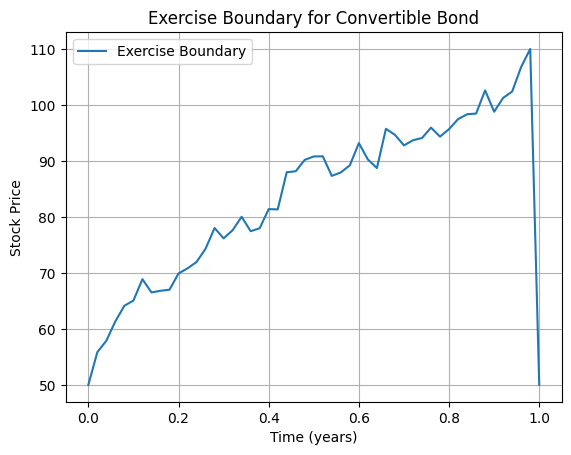

np.float64(1088.4580780425483)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
face_value = 1000
conversion_price = 50
conversion_ratio = face_value / conversion_price
r = 0.05  # risk-free rate
T = 1.0  # maturity in years
M = 50  # time steps
dt = T / M
coupon_rate = 0.04  # continuous coupon rate per annum
N = 10000  # number of simulated paths
sigma = 0.2  # volatility
S0 = 50  # initial stock price

# Simulate stock price paths using geometric Brownian motion
np.random.seed(0)
Z = np.random.standard_normal((N, M))
S = np.zeros((N, M + 1))
S[:, 0] = S0
for t in range(1, M + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Initialize bond values at maturity
bond_values = np.maximum(face_value, conversion_ratio * S[:, -1])

# Store exercise boundary at each time step
exercise_boundary = np.zeros(M + 1)

# Backward induction
for t in range(M - 1, -1, -1):
    accrued_coupons = coupon_rate * dt * face_value
    discounted_bond_values = np.exp(-r * dt) * bond_values + accrued_coupons

    # Regression to estimate continuation value
    X = np.vstack([np.ones(N), S[:, t], S[:, t]**2]).T
    Y = discounted_bond_values
    coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
    continuation_values = X @ coeffs

    conversion_values = conversion_ratio * S[:, t]

    exercise = conversion_values >= continuation_values

    bond_values = np.where(exercise, conversion_values, discounted_bond_values)

    # Estimate exercise boundary by max stock price where hold is better
    hold_indices = np.where(~exercise)[0]
    if len(hold_indices) > 0:
        exercise_boundary[t] = np.max(S[hold_indices, t])
    else:
        exercise_boundary[t] = 0

exercise_boundary[-1] = conversion_price  # at maturity

# Price is the average discounted bond value
price = np.mean(bond_values) * np.exp(-r * dt)

# Plot exercise boundary
plt.plot(np.linspace(0, T, M + 1), exercise_boundary, label='Exercise Boundary')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price')
plt.title('Exercise Boundary for Convertible Bond')
plt.grid(True)
plt.legend()
plt.show()

price

TIME DEPENDENT

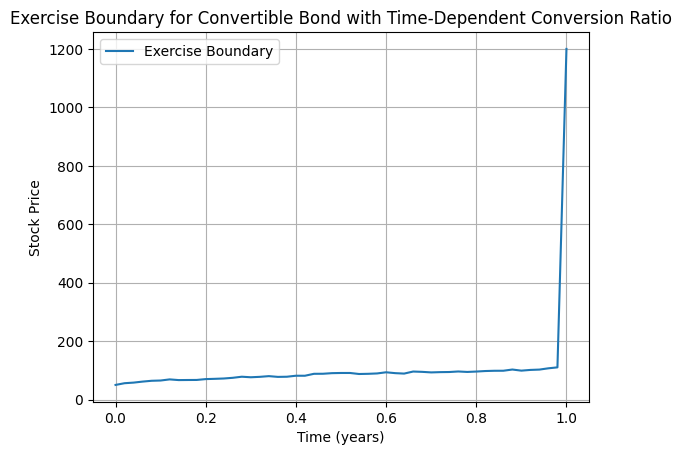

np.float64(1247.5998538194158)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
face_value = 1000
conversion_price_0 = 50
r = 0.05  # risk-free rate
T = 1.0  # maturity in years
M = 50  # time steps
dt = T / M
coupon_rate = 0.04  # continuous coupon rate per annum
N = 10000  # number of simulated paths
sigma = 0.2  # volatility
S0 = 50  # initial stock price

# Define time-dependent conversion ratio as a function of time (linear increase example)
def conversion_ratio(t):
    # Starts at face_value/conversion_price_0, increases by 20% linearly over time
    return (face_value / conversion_price_0) * (1 + 0.2 * t / T)

# Simulate stock price paths using geometric Brownian motion
np.random.seed(0)
Z = np.random.standard_normal((N, M))
S = np.zeros((N, M + 1))
S[:, 0] = S0
for t in range(1, M + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Initialize bond values at maturity
bond_values = np.maximum(face_value, conversion_ratio(T) * S[:, -1])

# Store exercise boundary at each time step
exercise_boundary = np.zeros(M + 1)

# Backward induction
for t in range(M - 1, -1, -1):
    accrued_coupons = coupon_rate * dt * face_value
    discounted_bond_values = np.exp(-r * dt) * bond_values + accrued_coupons

    # Regression to estimate continuation value
    X = np.vstack([np.ones(N), S[:, t], S[:, t]**2]).T
    Y = discounted_bond_values
    coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
    continuation_values = X @ coeffs

    conversion_vals = conversion_ratio(t * dt) * S[:, t]

    exercise = conversion_vals >= continuation_values

    bond_values = np.where(exercise, conversion_vals, discounted_bond_values)

    # Estimate exercise boundary by max stock price where hold is better
    hold_indices = np.where(~exercise)[0]
    if len(hold_indices) > 0:
        exercise_boundary[t] = np.max(S[hold_indices, t])
    else:
        exercise_boundary[t] = 0

exercise_boundary[-1] = conversion_ratio(T) * conversion_price_0  # at maturity

# Price is average discounted bond value (already discounted)
price = np.mean(bond_values)

# Plot exercise boundary
plt.plot(np.linspace(0, T, M + 1), exercise_boundary, label='Exercise Boundary')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price')
plt.title('Exercise Boundary for Convertible Bond with Time-Dependent Conversion Ratio')
plt.grid(True)
plt.legend()
plt.show()

price